In [1]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
#2
# Load combined dataset
data = pd.read_csv('../data/processed/all_stocks_combined.csv', index_col=0, parse_dates=True)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {list(data.columns)}")
print(f"\nDate range: {data.index.min()} to {data.index.max()}")
print(f"\nStocks: {data['Ticker'].unique()}")
print(f"\nFirst few rows:")
print(data.head())

Dataset shape: (1510, 16)

Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA_20', 'MA_50', 'MA_200', 'Volatility', 'Momentum', 'Volume_MA', 'Ticker', 'Year', 'Month', 'Day_of_Week']

Date range: 2024-12-04 00:00:00 to 2026-02-19 00:00:00

Stocks: ['AAPL' 'GOOGL' 'MSFT' 'AMZN' 'TSLA']

First few rows:
                 Close        High         Low        Open      Volume  \
Date                                                                     
2024-12-04  241.689728  242.783758  239.939295  241.550489  44383900.0   
2024-12-05  241.719559  243.211409  240.814514  242.664410  40033900.0   
2024-12-06  241.520630  243.300913  240.764764  241.590257  36870600.0   
2024-12-09  245.409409  245.896752  240.436574  240.516141  44649200.0   
2024-12-10  246.423874  246.861486  244.007068  245.548650  36914800.0   

            Daily_Return       MA_20       MA_50      MA_200  Volatility  \
Date                                                                       
2024-

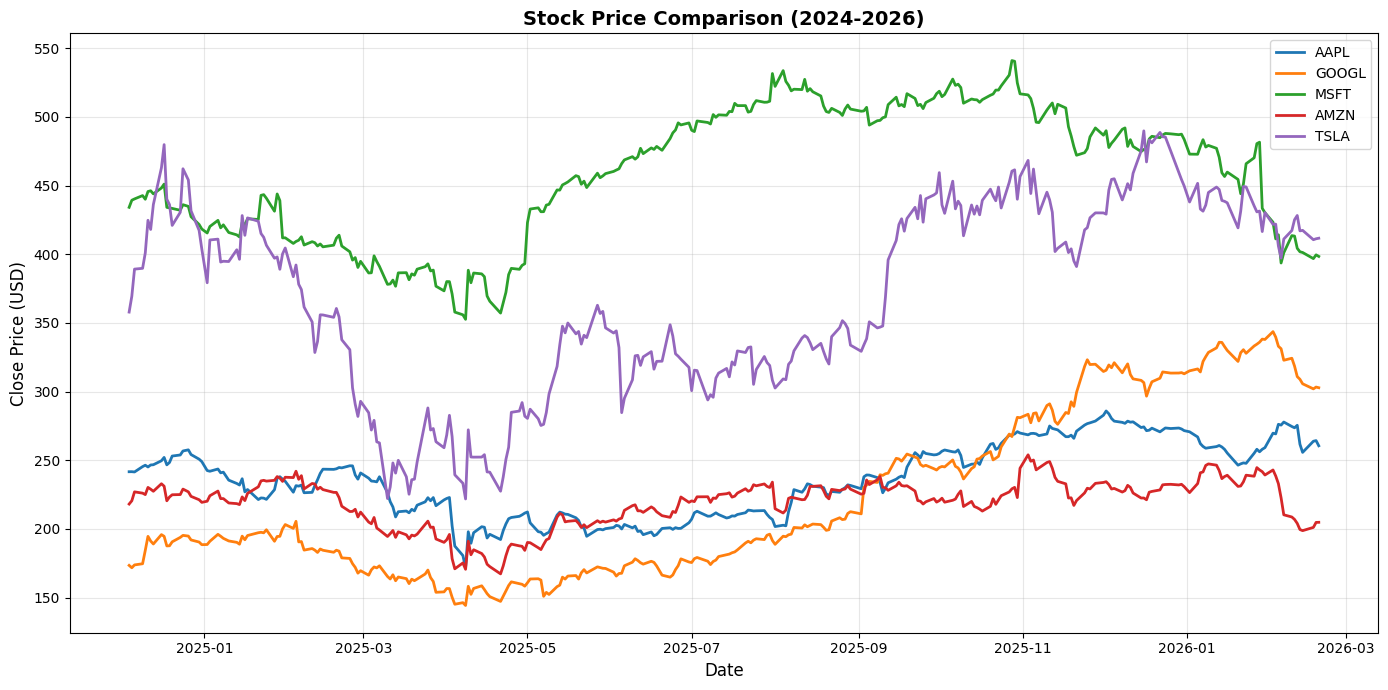

Chart saved!


In [3]:
#3
# Compare closing prices of all stocks
fig, ax = plt.subplots(figsize=(14, 7))

for ticker in data['Ticker'].unique():
    ticker_data = data[data['Ticker'] == ticker]
    ax.plot(ticker_data.index, ticker_data['Close'], label=ticker, linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price (USD)', fontsize=12)
ax.set_title('Stock Price Comparison (2024-2026)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../dashboards/screenshots/price_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved!")

Stock Volatility Ranking:
        Avg_Volatility  Return_StdDev
Ticker                               
TSLA            0.0369         0.0387
AMZN            0.0200         0.0213
GOOGL           0.0192         0.0199
AAPL            0.0168         0.0197
MSFT            0.0145         0.0164


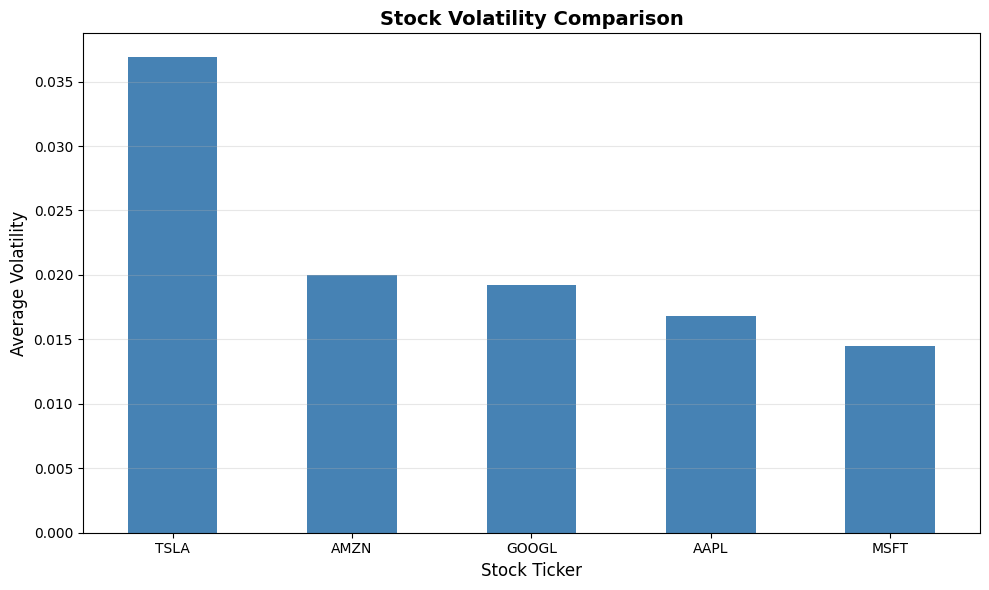

In [4]:
#4
# Calculate and compare volatility across stocks
volatility_summary = data.groupby('Ticker').agg({
    'Volatility': 'mean',
    'Daily_Return': 'std'
}).round(4)

volatility_summary.columns = ['Avg_Volatility', 'Return_StdDev']
volatility_summary = volatility_summary.sort_values('Avg_Volatility', ascending=False)

print("Stock Volatility Ranking:")
print(volatility_summary)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
volatility_summary['Avg_Volatility'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Stock Ticker', fontsize=12)
ax.set_ylabel('Average Volatility', fontsize=12)
ax.set_title('Stock Volatility Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../dashboards/screenshots/volatility_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

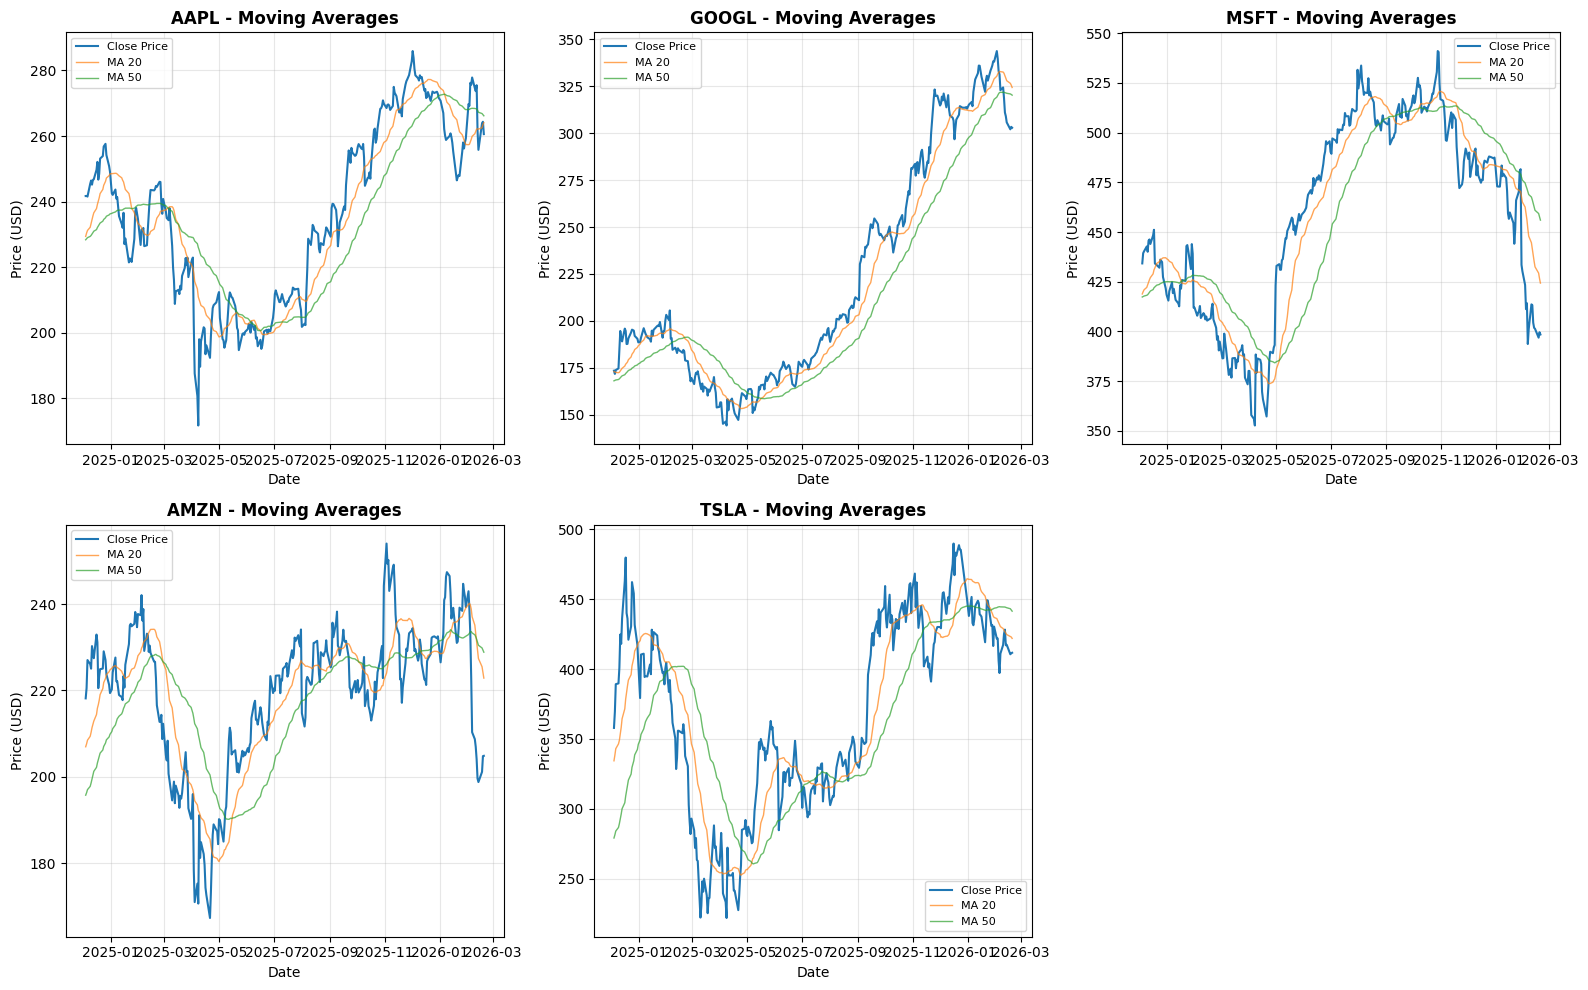

Moving average analysis complete!


In [5]:
#5
# Analyze buy/sell signals using moving averages
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, ticker in enumerate(data['Ticker'].unique()):
    ticker_data = data[data['Ticker'] == ticker].copy()
    
    ax = axes[idx]
    ax.plot(ticker_data.index, ticker_data['Close'], label='Close Price', linewidth=1.5)
    ax.plot(ticker_data.index, ticker_data['MA_20'], label='MA 20', linewidth=1, alpha=0.7)
    ax.plot(ticker_data.index, ticker_data['MA_50'], label='MA 50', linewidth=1, alpha=0.7)
    
    ax.set_title(f'{ticker} - Moving Averages', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../dashboards/screenshots/moving_averages.png', dpi=300, bbox_inches='tight')
plt.show()

print("Moving average analysis complete!")

Stock Performance Summary:
        Start_Price  End_Price  Avg_Daily_Return  Volatility  Total_Return_%
Ticker                                                                      
AAPL         241.69     260.58               0.0        0.02            7.82
AMZN         218.16     204.86               0.0        0.02           -6.10
GOOGL        173.49     302.85               0.0        0.02           74.56
MSFT         434.22     398.46              -0.0        0.02           -8.23
TSLA         357.93     411.71               0.0        0.04           15.03


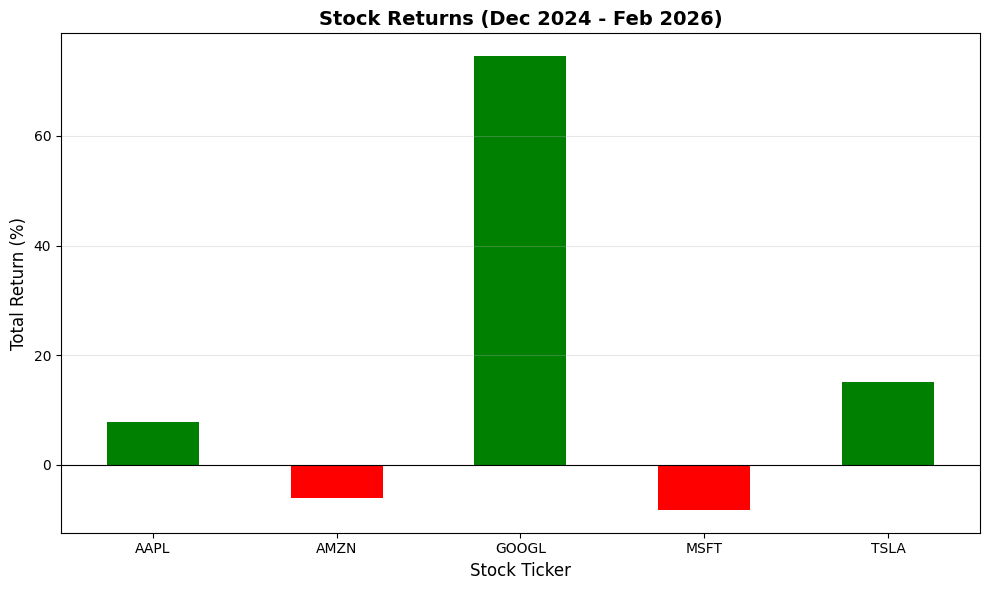

In [6]:
#6
# Calculate total returns for each stock
returns_summary = data.groupby('Ticker').agg({
    'Close': ['first', 'last'],
    'Daily_Return': ['mean', 'std']
}).round(4)

returns_summary.columns = ['Start_Price', 'End_Price', 'Avg_Daily_Return', 'Volatility']
returns_summary['Total_Return_%'] = ((returns_summary['End_Price'] / returns_summary['Start_Price']) - 1) * 100
returns_summary = returns_summary.round(2)

print("Stock Performance Summary:")
print(returns_summary)

# Visualize total returns
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in returns_summary['Total_Return_%']]
returns_summary['Total_Return_%'].plot(kind='bar', ax=ax, color=colors)
ax.set_xlabel('Stock Ticker', fontsize=12)
ax.set_ylabel('Total Return (%)', fontsize=12)
ax.set_title('Stock Returns (Dec 2024 - Feb 2026)', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../dashboards/screenshots/returns_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Stock Price Correlation Matrix:
Ticker   AAPL   AMZN  GOOGL   MSFT   TSLA
Ticker                                   
AAPL    1.000  0.599  0.849  0.266  0.825
AMZN    0.599  1.000  0.589  0.598  0.706
GOOGL   0.849  0.589  1.000  0.379  0.779
MSFT    0.266  0.598  0.379  1.000  0.463
TSLA    0.825  0.706  0.779  0.463  1.000


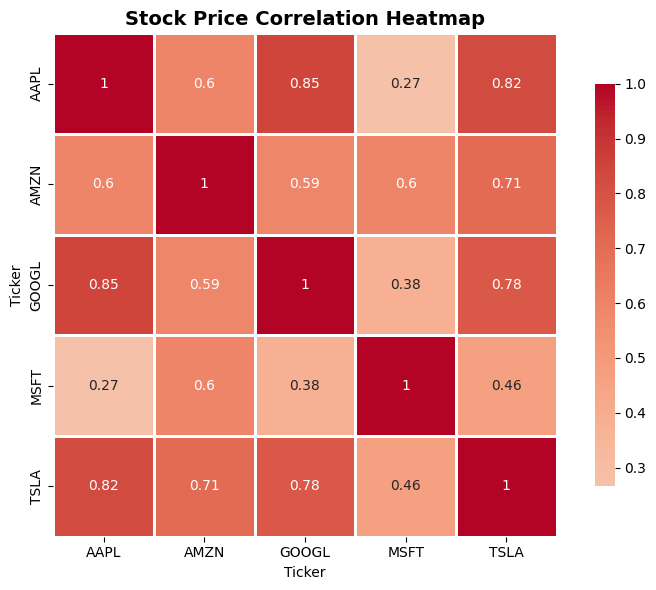


Insight: High correlation means stocks move together (diversification risk)


In [7]:
#7
# Calculate correlation between stocks
pivot_close = data.pivot_table(values='Close', index=data.index, columns='Ticker')
correlation_matrix = pivot_close.corr()

print("Stock Price Correlation Matrix:")
print(correlation_matrix.round(3))

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Stock Price Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboards/screenshots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInsight: High correlation means stocks move together (diversification risk)")